In [1]:
import warnings
warnings.filterwarnings('ignore')

  0%|          | 0/5 [00:02<?, ?it/s]
The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 1428.61it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]             


Checkpoint found in cache: /Users/legariapena.j/.cache/huggingface/hub/models--urilp4669--LCNN_Weights/snapshots/c6c07b7b538d8b7c16ca269b592677764c3ea6ca/190418-201834-f8934c6-lr4d10-312k.pth


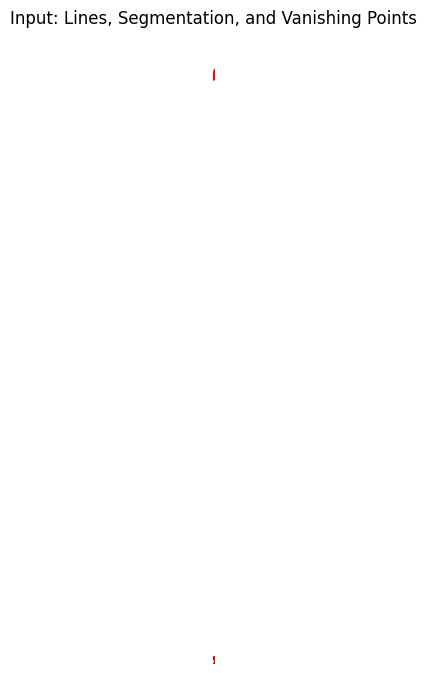

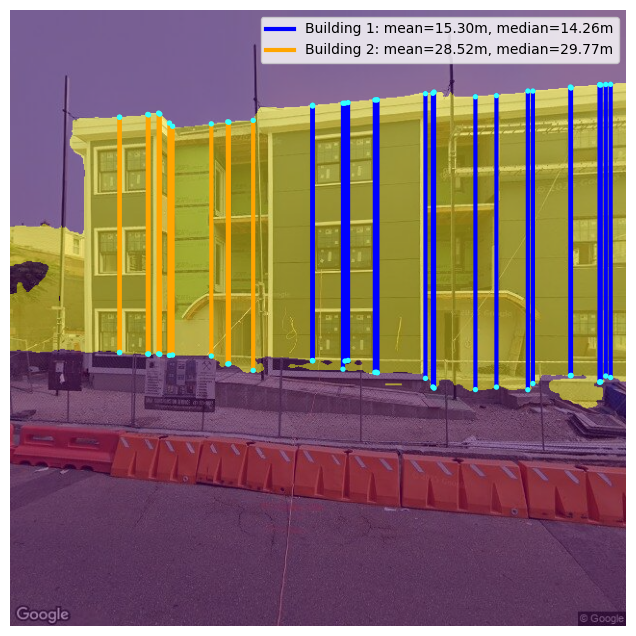

Estimated height: 10.724203627195353 meters


In [4]:
from imageable._features.height.building_height import HeightEstimationParameters, building_height_from_single_view, corrected_height_from_single_view
import geopandas as gpd


#Open the footprint
file_path = "/Users/legariapena.j/Library/CloudStorage/GoogleDrive-legariapena.j@husky.neu.edu/My Drive/Phd_Northeastern/Semester_1/RA/imageable/notebooks/tests_data/random_sample_200.geojson"
gdf = gpd.read_file(file_path)
polygon = gdf["geometry"][30]

#Define the height estimation parameters
#In the most basic version you only provide the GSV API key and the building footprint polygon
gsv_api_key = ""

height_parameters = HeightEstimationParameters(
    gsv_api_key=gsv_api_key,
    footprint=polygon,
    verbose=True
)

#Estimate the height with a single function call
height = corrected_height_from_single_view(height_parameters, building_id = "0", all_buildings = gdf["geometry"].to_list())
print(f"\033[32mEstimated height: {height} meters\033[0m")



In [3]:
from imageable._features.height.building_height import (
    HeightEstimationParameters,
    corrected_height_from_single_view,   # <-- the corrected version
)
import geopandas as gpd

# Open the footprints
file_path = "/Users/legariapena.j/Library/CloudStorage/GoogleDrive-legariapena.j@husky.neu.edu/My Drive/Phd_Northeastern/Semester_1/RA/imageable/notebooks/tests_data/random_sample_200.geojson"
gdf = gpd.read_file(file_path)
polygon = gdf["geometry"][building_id]
all_boston_gdf = gpd.read_file("/Users/legariapena.j/Library/CloudStorage/GoogleDrive-legariapena.j@husky.neu.edu/Shared drives/Cool and Carbon Free Africa/Building Image Datasets/data/boston/footprints/boston_buildings.geojson")
all_buildings = list(all_boston_gdf["geometry"]) 
    # neighbors → spatial features
building_id = 30
polygon = all_boston_gdf["geometry"][building_id]

gsv_api_key = ""

height_parameters = HeightEstimationParameters(
    gsv_api_key=gsv_api_key,
    footprint=polygon,
    verbose=True,
)

# Single call that ALSO applies the cluster height correction
corrected = corrected_height_from_single_view(
    height_estimation_parameters=height_parameters,
    building_id=building_id,
    all_buildings=all_buildings,
    crs=str(gdf.crs),
    verbose=True,
)
print(f"\033[32mCorrected height: {corrected} meters\033[0m")


NameError: name 'building_id' is not defined